In [1]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Inisialisasi Spark LENGKAP
spark = SparkSession.builder \
    .appName("ML_Turnover_Final") \
    .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://bda-minio:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "admin") \
    .config("spark.hadoop.fs.s3a.secret.key", "password123") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .getOrCreate()

print("✅ Spark Session berhasil diinisialisasi!")

✅ Spark Session berhasil diinisialisasi!


In [2]:
# 2. Tarik Data Gold dari MinIO
minio_gold_path = "s3a://datalake/gold/employee-attrition/"
print(f"📥 Membaca data Parquet dari: {minio_gold_path}...")
gold_df = spark.read.parquet(minio_gold_path)

# 3. Split Data
print("⚙️ Membagi data untuk proses Machine Learning...")
train_split, test_split = gold_df.randomSplit([0.8, 0.2], seed=42)

print(f"   - Data Training : {train_split.count():,} baris")
print(f"   - Data Testing  : {test_split.count():,} baris")
print("✅ Data siap untuk dimasukkan ke model Random Forest!")

📥 Membaca data Parquet dari: s3a://datalake/gold/employee-attrition/...
⚙️ Membagi data untuk proses Machine Learning...
   - Data Training : 47,836 baris
   - Data Testing  : 11,762 baris
✅ Data siap untuk dimasukkan ke model Random Forest!


In [3]:
# 1. Setup Model (Parameter dikosongkan untuk Tuning)
rf = RandomForestClassifier(labelCol="label", featuresCol="features", seed=42)

# 2. Evaluator
mc_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
roc_evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

# 3. Setup Grid Search untuk kombinasi parameter
paramGrid = (ParamGridBuilder()
             .addGrid(rf.numTrees, [20, 50, 100])
             .addGrid(rf.maxDepth, [5, 8, 12])
             .build())

# 4. Siapkan Cross Validation
cv = CrossValidator(estimator=rf,
                    estimatorParamMaps=paramGrid,
                    evaluator=roc_evaluator, # Fokus mencari AUC-ROC tertinggi
                    numFolds=3)

print("✅ Setup Model, Evaluator, dan Cross Validator selesai.")

✅ Setup Model, Evaluator, dan Cross Validator selesai.


In [4]:
print("⏳ Sedang melatih model dan mencari parameter terbaik (Cross Validation)...")

# Fit model ke data training (PROSES INI MENCIPTAKAN best_model)
cv_model = cv.fit(train_split) 
best_model = cv_model.bestModel

# Ekstrak parameter pemenang
best_numTrees = best_model.getNumTrees
best_maxDepth = best_model.getOrDefault("maxDepth")

print(f"✅ Tuning selesai! Parameter terbaik didapatkan:")
print(f"   - Jumlah Pohon (numTrees) : {best_numTrees}")
print(f"   - Kedalaman (maxDepth)    : {best_maxDepth}")

⏳ Sedang melatih model dan mencari parameter terbaik (Cross Validation)...
✅ Tuning selesai! Parameter terbaik didapatkan:
   - Jumlah Pohon (numTrees) : 100
   - Kedalaman (maxDepth)    : 12


In [5]:
# Ekstrak bobot raw dari model terbaik
importance = best_model.featureImportances.toArray()

try:
    # Tarik nama-nama fitur dari metadata
    attrs = gold_df.schema["features"].metadata["ml_attr"]["attrs"]
    list_attrs = attrs.get("numeric", []) + attrs.get("binary", []) + attrs.get("nominal", [])
    
    # Buat list mapping sementara
    mapping_data = []
    for x in sorted(list_attrs, key=lambda x: x["idx"]):
        encoded_name = x["name"]
        idx = x["idx"]
        mapping_data.append((encoded_name, importance[idx]))
        
    raw_feat_df = pd.DataFrame(mapping_data, columns=["Encoded_Feature", "Importance"])
    
    # Fungsi Agregasi: Potong nama OHE untuk mendapatkan nama fitur induk
    def get_parent_feature(name):
        if "_ohe_" in name:
            return name.split("_ohe_")[0]
        return name
        
    raw_feat_df["Generalized_Feature"] = raw_feat_df["Encoded_Feature"].apply(get_parent_feature)
    
    # Group by fitur induk dan jumlahkan nilai kepentingannya
    importance_df = raw_feat_df.groupby("Generalized_Feature")["Importance"].sum().reset_index()
    importance_df = importance_df.sort_values(by="Importance", ascending=False)
    
    print("--- 🏆 TOP 10 GENERALIZED FEATURE IMPORTANCE ---")
    print(importance_df.head(10))

except Exception as e:
    print(f"⚠️ Error saat memproses Feature Importance: {e}")

--- 🏆 TOP 10 GENERALIZED FEATURE IMPORTANCE ---
     Generalized_Feature  Importance
9              Job Level    0.228763
13        Marital Status    0.183468
19           Remote Work    0.115330
20     Work-Life Balance    0.079329
4     Distance from Home    0.039947
21      Years at Company    0.032493
16  Number of Promotions    0.032119
1     Company Reputation    0.030023
5        Education Level    0.029911
0                    Age    0.029129


In [6]:
# Lakukan Prediksi pada data testing
predictions = best_model.transform(test_split)

# Tarik skor dari masing-masing metrik
accuracy = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "accuracy"})
precision = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "weightedPrecision"})
recall = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "weightedRecall"})
f1 = mc_evaluator.evaluate(predictions, {mc_evaluator.metricName: "f1"})
auc_roc = roc_evaluator.evaluate(predictions) 

print("--- 📊 HASIL EVALUASI MODEL ---")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc_roc:.4f}\n")

--- 📊 HASIL EVALUASI MODEL ---
Accuracy  : 0.7471
Precision : 0.7471
Recall    : 0.7471
F1 Score  : 0.7471
AUC-ROC   : 0.8319



/tmp/ipykernel_1581/881419180.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x="Metric", y="Value", data=evaluation_df, palette="viridis")


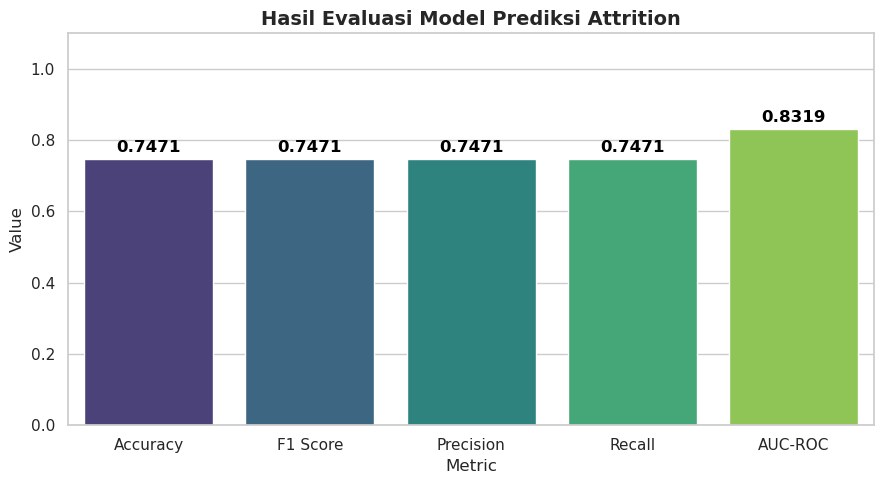

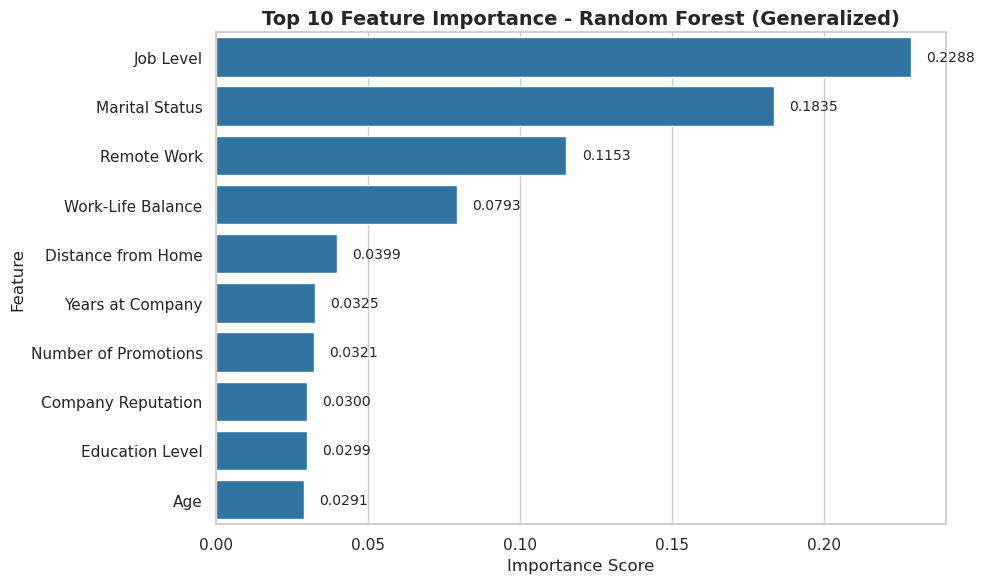

In [7]:
sns.set_theme(style="whitegrid")

# ==========================================
# 1. Visualisasi Evaluasi Model
# ==========================================
evaluation_df = pd.DataFrame({
    "Metric": ["Accuracy", "F1 Score", "Precision", "Recall", "AUC-ROC"],
    "Value": [accuracy, f1, precision, recall, auc_roc]
})

plt.figure(figsize=(9, 5))
bar_plot = sns.barplot(x="Metric", y="Value", data=evaluation_df, palette="viridis")
plt.title("Hasil Evaluasi Model Prediksi Attrition", fontsize=14, fontweight='bold')
plt.ylim(0, 1.1)

for index, row in evaluation_df.iterrows():
    plt.text(index, row.Value + 0.02, f'{row.Value:.4f}', color='black', ha="center", fontweight='bold')
    
plt.tight_layout()
plt.show()

# ==========================================
# 2. Visualisasi GENERAL Feature Importance
# ==========================================
plt.figure(figsize=(10, 6))

# Gunakan data agregasi dan warna biru solid yang profesional
sns.barplot(
    x="Importance", 
    y="Generalized_Feature", 
    data=importance_df.head(10), 
    color="#1f77b4" 
)

plt.title("Top 10 Feature Importance - Random Forest (Generalized)", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)

# Tambahkan angka skor persis di ujung tiap batang
for index, value in enumerate(importance_df.head(10)["Importance"]):
    plt.text(value + 0.005, index, f'{value:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [8]:
# Tampilkan Confusion Matrix
print("--- 🧮 CONFUSION MATRIX ---")
predictions.crosstab("label", "prediction").orderBy("label_prediction").show()

--- 🧮 CONFUSION MATRIX ---
+----------------+----+----+
|label_prediction| 0.0| 1.0|
+----------------+----+----+
|             0.0|4743|1492|
|             1.0|1483|4044|
+----------------+----+----+

